# MODEL VALIDATION ON THE IRIS DATASET

The idea is compile and fit a neural network model to the iris dataset, implement validation, regularisation and callback to improve the model

In [21]:
# Import Libraries

from numpy.random import seed
seed(8)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection


%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


<tr>
<td><img src="data/iris_setosa.jpg" alt="Drawing" style="height: 270px;"/></td>
<td><img src="data/iris_versicolor.jpg" alt="Drawing" style="height: 270px;"/></td>
<td><img src="data/iris_virginica.jpg" alt="Drawing" style="height: 270px;"/></td>
</tr>

# IRIS DATASET

Consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. For a reference, see the following papers:

The goal is to construct a neural network that classifies each sample into the correct class, as well as applying validation and regularisation techniques.

# Load and Preprocess the data

In [2]:
def read_in_and_split_data(iris_data):

    train_data, test_data, train_targets, test_targets = train_test_split(
        iris_data.data, iris_data.target, test_size=0.1)

    return (train_data, test_data, train_targets, test_targets)


In [3]:
iris_data = datasets.load_iris()
train_data, test_data, train_targets, test_targets = read_in_and_split_data(iris_data)

In [4]:
train_targets = tf.keras.utils.to_categorical(np.array(train_targets))
test_targets = tf.keras.utils.to_categorical(np.array(test_targets))

# BUILD THE NEURAL NETWORK

In [5]:

def get_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=input_shape, kernel_initializer='he_uniform',
              bias_initializer='ones'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])

    return model

    

In [6]:
model = get_model(train_data[0].shape)

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS\tf2-cnn-mnist-classifier\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,107 (309.01 KB)

 Trainable params: 79,107 (309.01 KB)

 Non-trainable params: 0 (0.00 B)

# COMPILE THE MODEL

In [8]:
def compile_model(model):

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics = ['accuracy'])

In [9]:
compile_model(model)

# MODEL FIT TO TRAINING DATA

In [10]:

def train_model(model, train_data, train_targets, epochs):

    history = model.fit(train_data, train_targets, epochs=epochs,
                        batch_size=40, validation_split=0.15)
    return history

In [11]:
history = train_model(model, train_data, train_targets, epochs=800)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5263 - loss: 1.0687 - val_accuracy: 0.9524 - val_loss: 0.9131
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8596 - loss: 0.8164 - val_accuracy: 0.6190 - val_loss: 0.7526
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.6226 - val_accuracy: 0.8095 - val_loss: 0.5898
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9561 - loss: 0.4557 - val_accuracy: 0.9048 - val_loss: 0.4913
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9211 - loss: 0.3735 - val_accuracy: 0.7143 - val_loss: 0.4673
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9386 - loss: 0.2912 - val_accuracy: 0.8571 - val_loss: 0.3741
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8947 - loss: 0.2721 - val_accuracy: 0.9048 - val_loss: 0.3234
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8947 - loss: 0.2335 - val_accuracy: 0.8571 - val_loss:

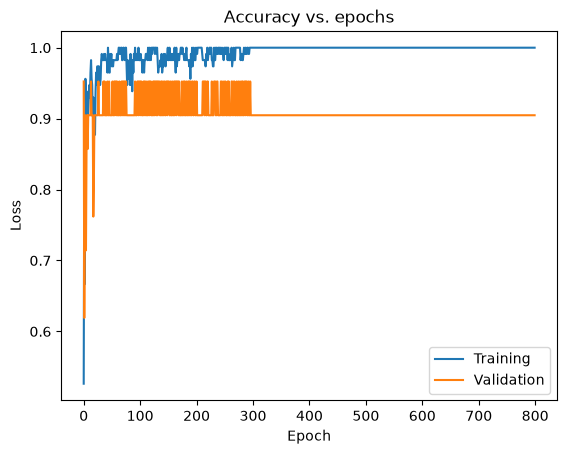

In [12]:
try:
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
except KeyError:
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

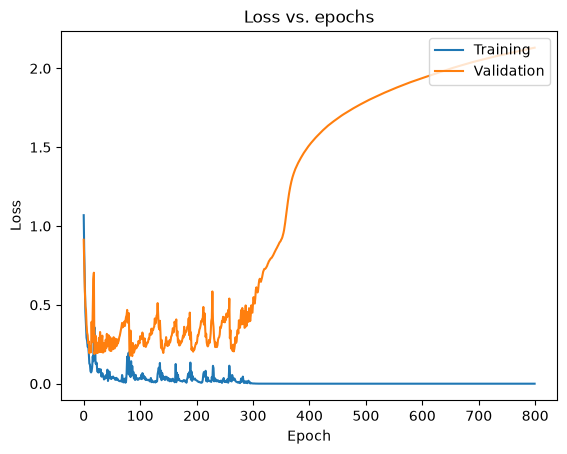

In [13]:
#Run this cell to plot the epoch vs loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can see overfit so we have to mitigate this overfitting.

# REDUCING OVERFITTING IN THE MODEL

In [15]:
def get_regularised_model(input_shape, dropout_rate, weight_decay):
    model = Sequential([
            Dense(64, activation='relu', input_shape=input_shape, kernel_initializer='he_uniform',
                  bias_initializer='ones', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dropout(dropout_rate),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            BatchNormalization(),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dropout(dropout_rate),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(3, activation='softmax')
        ])
    
    return model

# Compile and train the model

In [16]:
reg_model = get_regularised_model(train_data[0].shape, 0.3, 0.001)

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS\tf2-cnn-mnist-classifier\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
compile_model(reg_model)

In [18]:
reg_history = train_model(reg_model, train_data, train_targets, epochs=800)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4123 - loss: 1.9472 - val_accuracy: 0.1905 - val_loss: 1.9412
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 1.8680 - val_accuracy: 0.6190 - val_loss: 1.8520
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5175 - loss: 1.8151 - val_accuracy: 0.6190 - val_loss: 1.7674
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7193 - loss: 1.6542 - val_accuracy: 0.6190 - val_loss: 1.6518
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7281 - loss: 1.5147 - val_accuracy: 0.6190 - val_loss: 1.5582
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6930 - loss: 1.4433 - val_accuracy: 0.6190 - val_loss: 1.4750
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6930 - loss: 1.3534 - val_accuracy: 0.6190 - val_loss: 1.4016
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7456 - loss: 1.2822 - val_accuracy: 0.6190 - val_loss:

### Plot learning curves

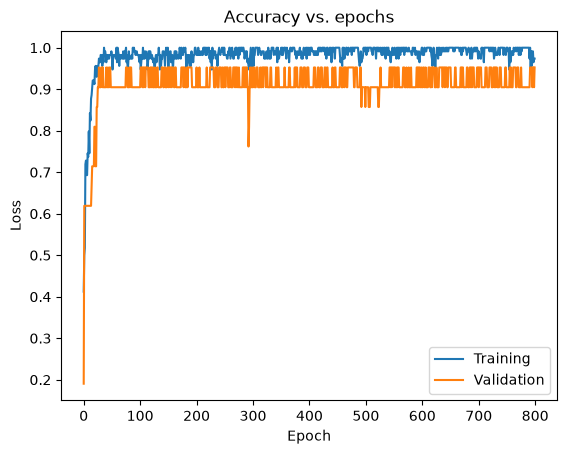

In [19]:
try:
    plt.plot(reg_history.history['accuracy'])
    plt.plot(reg_history.history['val_accuracy'])
except KeyError:
    plt.plot(reg_history.history['acc'])
    plt.plot(reg_history.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

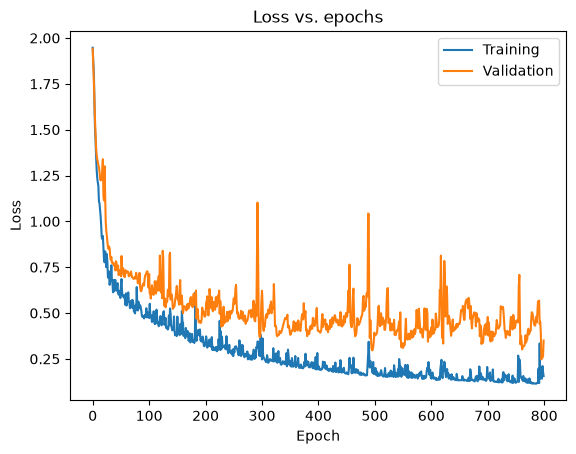

In [20]:
plt.plot(reg_history.history['loss'])
plt.plot(reg_history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can see that the regularisation has helped to reduce the overfitting of the network.
You will now incorporate callbacks into a new training run that implements early stopping and learning rate reduction on plateaux.